In [ ]:
# Provide three of the four parameters (a, e(L mol-1 cm-1), c(mol/L), l(m)) to calculate the missing one for the Beer-Lambert law.
def beerlambert(a=None, e=None, c=None, l=None):
    try:
        if a is None:
            return e * c * l
        elif e is None:
            return a / (c * l)
        elif c is None:
            return a / (e * l)
        elif l is None:
            return a / (e * c)
        else:
            raise ValueError
    except:
        print("Error: three of the four parameters (a, e(L mol-1 m-1), c(mol/L), l(m)) needed to calculate the missing one.")
        return None

# Provide two of the three parameters (m(g), M(g/mol), mol) to calculate the missing one for molar calculations.
def molcalc(m=None, M=None, mol=None):
    try:
        if m is None:
            return mol * M
        elif M is None:
            return m / mol
        elif mol is None:
            return m / M
        else:
            raise ValueError
    except:
        print("Error: two of the three parameters (m(g), M(g/mol), mol) needed to calculate the missing one.")
        return None

# Provide the three parameters (mol, v(L), c(mol/L)) to calculate the missing one for solution calculations.
def solcalc(mol=None, v=None, c=None):
    try:
        if mol is None:
            return v * c
        elif v is None:
            return mol / c
        elif c is None:
            return mol / v
        else:
            raise ValueError
    except:
        print("Error: three of the three parameters (mol, v(L), c(mol/L)) needed to calculate the missing one.")
        return None


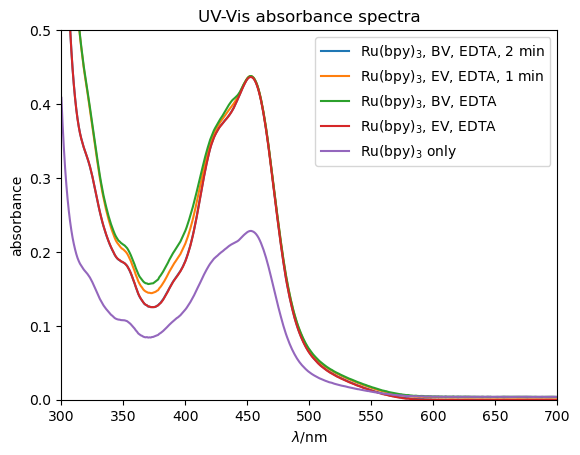

In [98]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# plotting the UV-Vis absorbance spectra from the .csv files in the results folder

labels = ['Ru(bpy)$_3$, BV, EDTA, 2 min',
          'Ru(bpy)$_3$, EV, EDTA, 1 min',
          'Ru(bpy)$_3$, BV, EDTA',
          'Ru(bpy)$_3$, EV, EDTA',
          'Ru(bpy)$_3$ only']

for i, f in enumerate(Path('./results').glob('*Raw.csv')):
    df = pd.read_csv(f)
    plt.plot(df.iloc[:, 0], df.iloc[:, 1], label=labels[i])

plt.xlim(300, 700)
plt.ylim(0, 0.5)
plt.xlabel(r'$\lambda$/nm')
plt.ylabel(r'absorbance')
plt.legend()
plt.title('UV-Vis absorbance spectra')
plt.show()

In [99]:
# find the extinction coefficient for the Ru(bpy)3 only sample in 1 cm cuvette

c = solcalc(# concentration of Ru(bpy)3 in 3 mL cuvette
            mol=solcalc( # moles of Ru(bpy)3 in 50uL of stock solution
                        c=solcalc( # concentration of Ru(bpy)3 in 25 mL stock solution
                                  molcalc(m=17.3e-3, M=640.53), # moles of Ru(bpy)3Cl2 in 17.3 mg
                                  v=25e-3), 
                        v=50e-6),
            v=3e-3)

df = pd.read_csv(Path('./results/Rubpy_50uLin3mL.Sample.Raw.csv'))
lamdamax, Amax = df.loc[df[(df.iloc[:,0] >=350)].iloc[:,1].idxmax()]
e = beerlambert(a=Amax, c=c, l=1e-2)
print(f'Ru(bpy)3: λmax = {lamdamax} nm, Amax = {Amax:.3f}, e = {e:.3f} L mol-1 m-1')


Ru(bpy)3: λmax = 453.0 nm, Amax = 0.228, e = 1268377.136 L mol-1 m-1


In [100]:
# find the concentration for 1% transmittance (i.e. A = 2) for Ru(bpy)3 in l = 700um chamber

c = beerlambert(a=2, e=e, l=700e-4)
print(f'Ru(bpy)3: c = {c:.3e} mol/L for 1% transmittance in 700 um chamber')

Ru(bpy)3: c = 2.253e-05 mol/L for 1% transmittance in 700 um chamber
